In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [7]:
df = pd.read_csv('/content/Rainfall.csv')


In [9]:
# Remove missing values
df = df.dropna()

In [10]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [11]:
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # rainfall (target)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestRegressor()

In [15]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [16]:
def evaluate(y_test, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("R2 Score:", r2)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression
RMSE: 9.478573470038642
R2 Score: 0.29466578151808753

Decision Tree
RMSE: 10.071892260078547
R2 Score: 0.20360021321405608

Random Forest
RMSE: 8.52600333387895
R2 Score: 0.4293103602573294


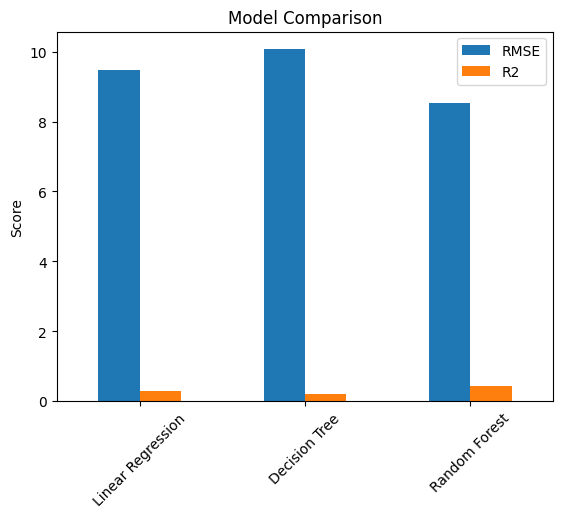

In [17]:
results = {
    "Linear Regression": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        r2_score(y_test, y_pred_lr)
    ],

    "Decision Tree": [
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        r2_score(y_test, y_pred_dt)
    ],

    "Random Forest": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        r2_score(y_test, y_pred_rf)
    ]
}

results_df = pd.DataFrame(results, index=["RMSE","R2"]).T

results_df.plot(kind='bar')
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

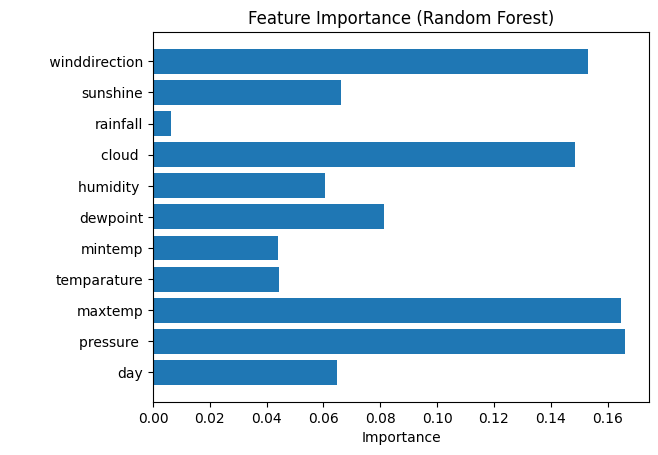

In [18]:
importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

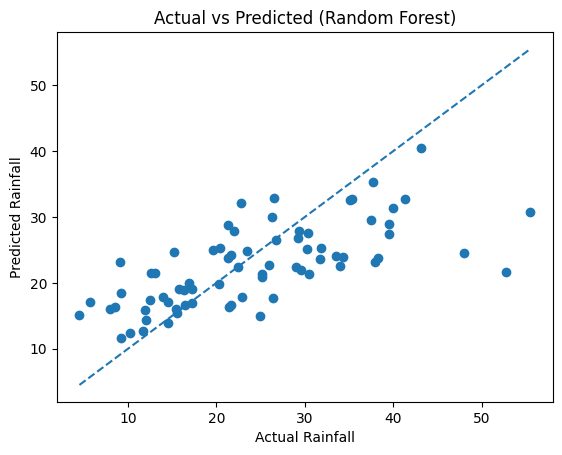

In [21]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted (Random Forest)")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.show()

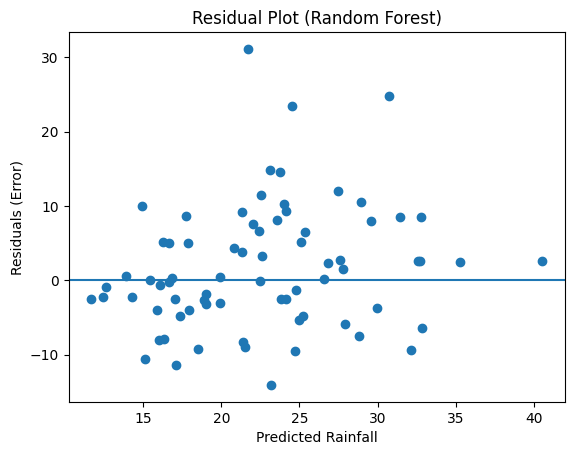

In [22]:
residuals = y_test - y_pred_rf

plt.figure()

plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Rainfall")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot (Random Forest)")

plt.show()